In [1]:
import gffpandas.gffpandas as gffpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
ctrl_ph7 = gffpd.read_gff3('../sample1_modification.gff') #Wild Type pH 7
arss_ph7 = gffpd.read_gff3('../sample2_modification.gff') #ArsS deletion pH 7, cannot detect pH change
ctrl_ph5 = gffpd.read_gff3('../sample5_modification.gff') #wild type pH 5
arss_ph5 = gffpd.read_gff3('../sample6_modification.gff') #ArsS deletion pH 5

counts = pd.read_csv('gene_counts.csv')
#NOTE ANNOT, COUNTS, AND FREQ ARE ALL DATA FRAMES, NOT GFF DATA FRAMES
annot = pd.read_csv("../hpy_annot.tsv",sep='\t')#hpy annotation file
annot = annot.drop(columns=["seqname", "source", "feature", "score", "frame", "Prot_Size(est)", "attribute"]) #clean

tss = pd.read_csv("../TSS.csv")

In [5]:
ctrl_ph7 = ctrl_ph7.attributes_to_columns()
ctrl_ph5 = ctrl_ph5.attributes_to_columns()

arss_ph7 = arss_ph7.attributes_to_columns()
arss_ph5 = arss_ph5.attributes_to_columns()

ctrl_ph7 = ctrl_ph7[ctrl_ph7['IPDRatio'] >= '2']
ctrl_ph5 = ctrl_ph5[ctrl_ph5['IPDRatio'] >= '2']

arss_ph7 = arss_ph7[arss_ph7['IPDRatio'] >= '2']
arss_ph5 = arss_ph5[arss_ph5['IPDRatio'] >= '2']

In [6]:
merge = pd.read_csv('methylation_df.csv')

In [7]:
merge

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
0,0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,...,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535.0,GAGG,Intergenic Region,NaN,NaN,NaN,NaN
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,...,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,...,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,...,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,...,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237125,237125,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,...,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663.0,GATC,Coding Region,NaN,HP1589,HYPOTHETICAL PROTEIN,NaN
237126,237126,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,...,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447.0,DGAAGG,Coding Region,NaN,HP1589,HYPOTHETICAL PROTEIN,NaN
237127,237127,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,...,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451.0,RCGDAD,Coding Region,NaN,HP1589,HYPOTHETICAL PROTEIN,NaN
237128,237128,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,...,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644.0,GAAGA,Coding Region,NaN,HP1590,HYPOTHETICAL PROTEIN,NaN


In [20]:
ctrl_ph7 = merge[merge['sample'] == 'ctrl pH7']
ctrl_ph5 = merge[merge['sample'] == 'ctrl pH5']

In [21]:
ph7_unique = ctrl_ph7[~ctrl_ph7['start'].isin(ctrl_ph5['start'])]
ph5_unique = ctrl_ph5[~ctrl_ph5['start'].isin(ctrl_ph7['start'])]
wt_differences = pd.concat([ph7_unique, ph5_unique])
wt_differences.reset_index(drop=True, inplace=True)

In [6]:
ph5_unique

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
59714,59714,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,996,996,93,-,.,...,ATTGCAAGAAGGGGCGATGGACTGCTTTAAAAGGCATGGGG,460,NaN,66.0,NaN,Coding Region,NaN,HP0002,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",NaN
59791,59791,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,3061,3061,152,+,.,...,GCCCCTTGATTATGGGCGTGAGCGCTTTAACCAGCTTTAGC,450,NaN,84.0,NaN,Coding Region,NaN,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",NaN
59795,59795,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,3088,3088,143,-,.,...,GTTATACACCATCAAAAATTCCTCTTCGCTAAAGCTGGTTA,455,NaN,114.0,NaN,Coding Region,NaN,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",NaN
60145,60145,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,12842,12842,146,-,.,...,GATATAAAAAGGGAATAGCCCCTTAGGGGCGTCCTTTTCTT,472,NaN,123.0,NaN,Coding Region,NaN,HP0014,HYPOTHETICAL PROTEIN,NaN
60458,60458,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,21862,21862,110,-,.,...,TAGATTCTTCTTTTAAAAACAACGCTTATGAAAATTTGCCA,448,NaN,108.0,NaN,Coding Region,NaN,HP0022,HYPOTHETICAL PROTEIN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118679,118679,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,1648914,1648914,80,-,.,...,CATGACTAAAAAGGAATTTCTAGTCCCTACAAGGGGAAATA,436,NaN,NaN,NaN,Coding Region,NaN,HP1565,CELL ENVELOPE,NaN
118761,118761,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1651173,1651173,94,-,.,...,GATTAGTGTTTTTCTTTTTGCGTTCCCAACCCACTAGCGTA,444,NaN,59.0,NaN,Coding Region,NaN,HP1569,HYPOTHETICAL PROTEIN,NaN
118876,118876,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1653947,1653947,129,-,.,...,AAATTGCTGAAATCATCAACATAGAGACTGAAGAACTCGCT,434,NaN,86.0,NaN,Coding Region,NaN,HP1573,HYPOTHETICAL PROTEIN,NaN
118897,118897,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1654536,1654536,92,-,.,...,ACTCAATGCGTGATTCCTGGCGCGGACATGAAGGATTTGAA,432,NaN,48.0,NaN,Coding Region,NaN,HP1573,HYPOTHETICAL PROTEIN,NaN


In [8]:
ph7_unique['motif'].value_counts()

motif
HHTCAVNNNNNNTGY    64
RCGDAD             14
TCTTC              11
GAGG                5
ATTAAT              4
GAAGA               1
GAAGA,GATC          1
Name: count, dtype: int64

In [9]:
ph5_unique['motif'].value_counts()

motif
HTCAVNNNNNNTGY      68
RCGDAD              39
ACAGNNNNNNTGA       10
GAGG                 9
TCTTC                9
GCGCGVATNNNNNNNH     8
ACANNNNNNNNTAG       2
GANTC                2
RCGDAD,GAGG          1
GCAG                 1
GATC                 1
Name: count, dtype: int64

In [36]:
wt_differences.to_csv('./ctrl_diff.csv.')

In [11]:
wt_differences['promoter_ID'].value_counts()

promoter_ID
HP0222      1
HP0317      1
HP0543      1
HP0777      1
HP1162      1
HP1399      1
HP0408      1
HP0923      1
HPnc7100    1
HP1414      1
HP1457      1
HPnc7890    1
Name: count, dtype: int64

In [35]:
wt_differences[wt_differences['gene_ID'] == 'HP0922']

KeyError: 'gene_ID'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming ph7_unique and ph5_unique DataFrames already exist

# Get value counts for gene_type in both dataframes
ph7_gene_type_counts = ph7_unique['gene_type'].value_counts()
ph5_gene_type_counts = ph5_unique['gene_type'].value_counts()

# Align both dataframes to have the same index (all unique gene types)
all_gene_types = sorted(set(ph7_gene_type_counts.index).union(ph5_gene_type_counts.index))
ph7_counts_aligned = ph7_gene_type_counts.reindex(all_gene_types, fill_value=0)
ph5_counts_aligned = ph5_gene_type_counts.reindex(all_gene_types, fill_value=0)

# Set the bar width
bar_width = 0.35
index = np.arange(len(all_gene_types))  # The x locations for the groups

# Create the bar plots
fig, ax = plt.subplots(figsize=(12, 6))
bar1 = ax.bar(index, ph7_counts_aligned.values, bar_width, label='ph7_unique', color='blue')
bar2 = ax.bar(index + bar_width, ph5_counts_aligned.values, bar_width, label='ph5_unique', color='green')

# Add labels, title, and ticks
ax.set_xlabel('Gene Type')
ax.set_ylabel('Counts')
ax.set_title('Gene Type Counts Comparison: ph7_unique vs ph5_unique')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(all_gene_types, rotation=90)  # Rotate x labels for readability
ax.legend()



# Show the plot
plt.show()


In [ ]:
cellevelope_wt = wt_differences[wt_differences['Promoter_gene_type'] == 'CELL ENVELOPE']

In [ ]:
counts[counts['gene'] == 'HP0208']

In [ ]:
unique_gene_ids = cellevelope_wt['gene_ID'].unique()
filtered_annot = annot[annot['HP_number'].isin(unique_gene_ids)]
filtered_annot

In [ ]:
cellevelope_wt[cellevelope_wt['gene_ID'] == 'HP1565']

In [ ]:
counts[counts['gene'] == 'HP1565']

In [ ]:
merged_df = pd.merge(merge_cellenv, env[['HP_number', 'Unnamed: 4']], left_on='gene_ID', right_on='HP_number', how='left')

In [ ]:
merged_df.rename(columns={'Unnamed: 4': 'Envelope Type'}, inplace=True)

In [13]:
selected_columns = ['HP_number', 'Envelope Type', 'Orf_Size', 'strand']
clean = env[selected_columns]

NameError: name 'env' is not defined

In [14]:
gene_id_counts = cellenv_c7['gene_ID'].value_counts().reset_index()
gene_id_counts.columns = ['HP_number', 'count']  # Renaming columns for clarity

merged_df = pd.merge(clean, gene_id_counts, how='left', left_on='HP_number', right_on='HP_number')
merged_df['count'] = merged_df['count'].fillna(0)

NameError: name 'cellenv_c7' is not defined

In [15]:
merged_df['freq'] = merged_df['count'] / merged_df['Orf_Size']

NameError: name 'merged_df' is not defined

In [16]:
merged_df #save for error bars

NameError: name 'merged_df' is not defined

## acid senative changes in del-arsS

In [22]:
ars_ph7 = merge[merge['sample'] == 'arsS pH7']
ars_ph5 = merge[merge['sample'] == 'arsS pH5']

ars7_unique = ars_ph7[~ars_ph7['start'].isin(ars_ph5['start'])]
ars5_unique = ars_ph5[~ars_ph5['start'].isin(ars_ph7['start'])]

ars_differences = pd.concat([ars7_unique, ars5_unique])
ars_differences.reset_index(drop=True, inplace=True)

In [23]:
ars_differences.to_csv('./ars_diff.csv')

In [9]:
ars7_unique

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
119421,119421,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,113,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,531,NaN,71.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
119451,119451,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2946,2946,132,+,.,...,GCAAATGCCGCACTAGAATGCGCGAAATTAGACATTGACAT,520,NaN,63.0,NaN,Coding Region,NaN,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",NaN
119726,119726,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,10528,10528,101,+,.,...,GCTCAAGTGGTGGGTTTTGGAGGGCGCACCTTAAAAGAAAA,535,GAGG,121.0,GAGG,Coding Region,NaN,HP0012,REPLICATION,NaN
119809,119809,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,12842,12842,108,-,.,...,GATATAAAAAGGGAATAGCCCCTTAGGGGCGTCCTTTTCTT,452,NaN,104.0,NaN,Coding Region,NaN,HP0014,HYPOTHETICAL PROTEIN,NaN
120027,120027,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,19392,19392,114,+,.,...,TGCTACGTGTTAGAGAGCGAACGCTTAGAAAAAAACGCCAA,549,NaN,69.0,NaN,Coding Region,NaN,HP0020,CENTRAL INTERMEDIARY METABOLISM,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177545,177545,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1647120,1647120,155,+,.,...,TTAGAATAAAGCCAAAAATACAGCAAGCCTAAATCTCATTA,508,NaN,123.0,NaN,Intergenic Region,NaN,NaN,NaN,NaN
177921,177921,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1657734,1657734,117,+,.,...,GTCTTGGTGGATGATTTCAAACCGAATGGGTAAGGAAGCTT,533,NaN,4.0,NaN,Coding Region,NaN,HP1578,CELL ENVELOPE,NaN
178049,178049,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1661514,1661514,125,-,.,...,AGATACAACGGCTCACAAAGCGCGCTCACTTCCTTATGGCT,583,NaN,98.0,NaN,Coding Region,NaN,HP1583,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",NaN
178116,178116,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1663728,1663728,255,+,.,...,ACCGGGTTTAAAAAATCTCGCGCGGATTTTAACGACTTGTT,595,NaN,38.0,NaN,Coding Region,NaN,HP1585,CELL ENVELOPE,NaN


In [19]:
ars_differences

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
0,119421,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,113,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,531,NaN,71.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
1,119451,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2946,2946,132,+,.,...,GCAAATGCCGCACTAGAATGCGCGAAATTAGACATTGACAT,520,NaN,63.0,NaN,Coding Region,NaN,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",NaN
2,119726,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,10528,10528,101,+,.,...,GCTCAAGTGGTGGGTTTTGGAGGGCGCACCTTAAAAGAAAA,535,GAGG,121.0,GAGG,Coding Region,NaN,HP0012,REPLICATION,NaN
3,119809,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,12842,12842,108,-,.,...,GATATAAAAAGGGAATAGCCCCTTAGGGGCGTCCTTTTCTT,452,NaN,104.0,NaN,Coding Region,NaN,HP0014,HYPOTHETICAL PROTEIN,NaN
4,120027,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,19392,19392,114,+,.,...,TGCTACGTGTTAGAGAGCGAACGCTTAGAAAAAAACGCCAA,549,NaN,69.0,NaN,Coding Region,NaN,HP0020,CENTRAL INTERMEDIARY METABOLISM,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,236239,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1642245,1642245,109,+,.,...,AGCGATTGTTACAAGCGAGCATAGGATTTTGCGCCTGAAAT,455,NaN,53.0,NaN,Coding Region,NaN,HP1560,CELLULAR PROCESSES,NaN
787,236417,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1646956,1646956,161,+,.,...,AGCGATAATTTCTTAAAAAGCGTTATTTCTTAAGGGGGGGG,473,NaN,129.0,NaN,Intergenic Region,NaN,NaN,NaN,NaN
788,236605,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1652478,1652478,148,+,.,...,GCTATCTTGCGAATCGGAGTAGCGTTTGAAATGGCGTTCAA,428,NaN,111.0,NaN,Coding Region,NaN,HP1571,CELL ENVELOPE,NaN
789,236921,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1661662,1661662,116,+,.,...,CTAGCACGATAGGCAAAGTCAGCGCTCAAAGCGGGGCGTAT,439,NaN,74.0,NaN,Coding Region,NaN,HP1583,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",NaN


In [20]:
ars7_unique

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
119421,119421,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,113,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,531,NaN,71.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
119451,119451,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2946,2946,132,+,.,...,GCAAATGCCGCACTAGAATGCGCGAAATTAGACATTGACAT,520,NaN,63.0,NaN,Coding Region,NaN,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",NaN
119726,119726,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,10528,10528,101,+,.,...,GCTCAAGTGGTGGGTTTTGGAGGGCGCACCTTAAAAGAAAA,535,GAGG,121.0,GAGG,Coding Region,NaN,HP0012,REPLICATION,NaN
119809,119809,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,12842,12842,108,-,.,...,GATATAAAAAGGGAATAGCCCCTTAGGGGCGTCCTTTTCTT,452,NaN,104.0,NaN,Coding Region,NaN,HP0014,HYPOTHETICAL PROTEIN,NaN
120027,120027,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,19392,19392,114,+,.,...,TGCTACGTGTTAGAGAGCGAACGCTTAGAAAAAAACGCCAA,549,NaN,69.0,NaN,Coding Region,NaN,HP0020,CENTRAL INTERMEDIARY METABOLISM,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177545,177545,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1647120,1647120,155,+,.,...,TTAGAATAAAGCCAAAAATACAGCAAGCCTAAATCTCATTA,508,NaN,123.0,NaN,Intergenic Region,NaN,NaN,NaN,NaN
177921,177921,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1657734,1657734,117,+,.,...,GTCTTGGTGGATGATTTCAAACCGAATGGGTAAGGAAGCTT,533,NaN,4.0,NaN,Coding Region,NaN,HP1578,CELL ENVELOPE,NaN
178049,178049,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1661514,1661514,125,-,.,...,AGATACAACGGCTCACAAAGCGCGCTCACTTCCTTATGGCT,583,NaN,98.0,NaN,Coding Region,NaN,HP1583,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",NaN
178116,178116,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1663728,1663728,255,+,.,...,ACCGGGTTTAAAAAATCTCGCGCGGATTTTAACGACTTGTT,595,NaN,38.0,NaN,Coding Region,NaN,HP1585,CELL ENVELOPE,NaN


In [21]:
ars_differences['Promoter_gene_type'].value_counts()

Promoter_gene_type
HYPOTHETICAL PROTEIEN             2
CELL ENVELOPE                     1
TRANSPORT AND BINDING PROTEINS    1
ENERGY METABOLISM                 1
Name: count, dtype: int64

In [22]:
ars_differences['gene_ID'].value_counts()

KeyError: 'gene_ID'

In [23]:
ars5_unique['gene_ID'].value_counts()

KeyError: 'gene_ID'

In [24]:
annot[annot['HP_number'] == 'HP0463']

NameError: name 'annot' is not defined

In [25]:
ars_differences['gene_type'].value_counts()

KeyError: 'gene_type'

In [26]:
ars7_gene_type_counts = ars7_unique['gene_type'].value_counts()
ars5_gene_type_counts = ars5_unique['gene_type'].value_counts()

all_gene_types = sorted(set(ars7_gene_type_counts.index).union(ars5_gene_type_counts.index))
ph7_counts_aligned = ars7_gene_type_counts.reindex(all_gene_types, fill_value=0)
ph5_counts_aligned = ars5_gene_type_counts.reindex(all_gene_types, fill_value=0)

# Set the bar width
bar_width = 0.35
index = np.arange(len(all_gene_types))  # The x locations for the groups

# Create the bar plots
fig, ax = plt.subplots(figsize=(12, 6))
bar1 = ax.bar(index, ph7_counts_aligned.values, bar_width, label='ph7_unique', color='blue')
bar2 = ax.bar(index + bar_width, ph5_counts_aligned.values, bar_width, label='ph5_unique', color='green')

# Add labels, title, and ticks
ax.set_xlabel('Gene Type')
ax.set_ylabel('Counts')
ax.set_title('Gene Type Counts Comparison: ph7_unique vs ph5_unique')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(all_gene_types, rotation=90)  # Rotate x labels for readability
ax.legend()
plt.show()

KeyError: 'gene_type'

In [27]:
cellevelope_ars = ars_differences[ars_differences['gene_type'] == 'CELL ENVELOPE']

KeyError: 'gene_type'

In [28]:
cellevelope_ars['gene_ID'].value_counts()

NameError: name 'cellevelope_ars' is not defined

In [29]:
unique_gene_ids = cellevelope_ars['gene_ID'].unique()
filtered_annot = annot[annot['HP_number'].isin(unique_gene_ids)]
filtered_annot

NameError: name 'cellevelope_ars' is not defined

In [30]:
annot[annot['HP_number'] == 'HP0922']

NameError: name 'annot' is not defined

## Differences only from arsS system

In [31]:
# converge the ctrl ph 7 and 5 on having same values 

In [10]:
acid_df = pd.merge(ctrl_ph7, ctrl_ph5, on='start', how='inner', suffixes=('_ph7', '_ph5'))
acid_df

,Unnamed: 0_ph7,sample_ph7,seq_id_ph7,source_ph7,type_ph7,start,end_ph7,score_ph7,strand_ph7,phase_ph7,...,context_ph5,coverage_ph5,id_ph5,identificationQv_ph5,motif_ph5,Classification_ph5,promoter_ID_ph5,CodingRegion_ID_ph5,CodingRegion_gene_type_ph5,Promoter_gene_type_ph5
0,0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,...,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,474,GAGG,484.0,GAGG,Intergenic Region,NaN,NaN,NaN,NaN
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,...,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,475,GANTC,596.0,GANTC,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,...,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,473,GANTC,535.0,GANTC,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,...,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,480,RCGDAD,582.0,RCGDAD,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,...,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,470,RCGDAD,590.0,RCGDAD,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59130,59673,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,762,-,.,...,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,468,GATC,726.0,GATC,Coding Region,NaN,HP1589,HYPOTHETICAL PROTEIN,NaN
59131,59674,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,575,-,.,...,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,454,DGAAGG,475.0,DGAAGG,Coding Region,NaN,HP1589,HYPOTHETICAL PROTEIN,NaN
59132,59675,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,555,+,.,...,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,459,RCGDAD,460.0,RCGDAD,Coding Region,NaN,HP1589,HYPOTHETICAL PROTEIN,NaN
59133,59677,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,736,-,.,...,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,469,GAAGA/TCTTC,665.0,GAAGA,Coding Region,NaN,HP1590,HYPOTHETICAL PROTEIN,NaN


In [11]:
ctrl_ph7

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
0,0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,...,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535.0,GAGG,Intergenic Region,NaN,NaN,NaN,NaN
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,...,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,...,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,...,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,...,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59674,59674,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,575,-,.,...,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,541,DGAAGG,556.0,DGAAGG,Coding Region,NaN,HP1589,HYPOTHETICAL PROTEIN,NaN
59675,59675,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,555,+,.,...,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,555,RCGDAD,526.0,RCGDAD,Coding Region,NaN,HP1589,HYPOTHETICAL PROTEIN,NaN
59676,59676,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667716,1667716,125,+,.,...,AACTTGTCAATTATTCATTCATTCTTAGTGTGCCATCTTCA,561,NaN,69.0,NaN,Coding Region,NaN,HP1590,HYPOTHETICAL PROTEIN,NaN
59677,59677,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,736,-,.,...,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,553,GAAGA/TCTTC,776.0,GAAGA,Coding Region,NaN,HP1590,HYPOTHETICAL PROTEIN,NaN


In [13]:
merge

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
0,0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,...,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535.0,GAGG,Intergenic Region,NaN,NaN,NaN,NaN
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,...,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,...,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,...,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,...,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,Coding Region,NaN,HP0001,TRANSCRIPTION,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237125,237125,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,...,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663.0,GATC,Coding Region,NaN,HP1589,HYPOTHETICAL PROTEIN,NaN
237126,237126,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,...,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447.0,DGAAGG,Coding Region,NaN,HP1589,HYPOTHETICAL PROTEIN,NaN
237127,237127,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,...,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451.0,RCGDAD,Coding Region,NaN,HP1589,HYPOTHETICAL PROTEIN,NaN
237128,237128,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,...,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644.0,GAAGA,Coding Region,NaN,HP1590,HYPOTHETICAL PROTEIN,NaN


In [14]:
merge[merge['CodingRegion_ID'] == 'HP0464']

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
17304,17304,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,482788,482788,678,+,.,...,GCAATAAAGCGTTATTAGGCATGCGGATTTCCTTGATGGTG,516,CATG,674.0,CATG,Coding Region,NaN,HP0464,REPLICATION,NaN
17305,17305,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,482789,482789,443,-,.,...,CCACCATCAAGGAAATCCGCATGCCTAATAACGCTTTATTG,504,CATG,435.0,CATG,Coding Region,NaN,HP0464,REPLICATION,NaN
17306,17306,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,482794,482794,627,+,.,...,AAGCGTTATTAGGCATGCGGATTTCCTTGATGGTGGTTTTG,514,RCGDAD,633.0,RCGDAD,Coding Region,NaN,HP0464,REPLICATION,NaN
17307,17307,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,482877,482877,314,+,.,...,TTTTTCTAAATCTTTTAAGGAGGGGTCTTTTTTGAAAGCGT,513,GAGG,315.0,GAGG,Coding Region,NaN,HP0464,REPLICATION,NaN
17308,17308,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,482908,482908,690,-,.,...,CTAAAAAATGCCATAAAAGCAGAATTAAATAACGCTTTCAA,499,GCAG,650.0,GCAG,Coding Region,NaN,HP0464,REPLICATION,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195408,195408,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,485523,485523,321,+,.,...,TTTGATGTGGCGATCTCTTTCTTCTTTAATGCCTTTTTTGG,318,GAAGA/TCTTC,332.0,TCTTC,Coding Region,NaN,HP0464,REPLICATION,NaN
195409,195409,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,485547,485547,403,+,.,...,TTTAATGCCTTTTTTGGCGTAAGGCTGTTTAACTTCTATAT,326,RCGDAD,356.0,RCGDAD,Coding Region,NaN,HP0464,REPLICATION,NaN
195410,195410,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,485683,485683,451,+,.,...,TTATCAAAGTCTATGATTTGATTCTCGCTTTTGAGCAAGTA,332,GANTC,421.0,GANTC,Coding Region,NaN,HP0464,REPLICATION,NaN
195411,195411,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,485685,485685,507,-,.,...,AATACTTGCTCAAAAGCGAGAATCAAATCATAGACTTTGAT,346,GANTC,493.0,GANTC,Coding Region,NaN,HP0464,REPLICATION,NaN


In [24]:
annot

,HP_number,start,end,Putative_Id,Orf_Size,strand
0,HP0001,220,633,transcription termination factor NusB (nusB) {...,413,-
1,HP0002,638,1105,riboflavin synthase beta chain (ribE) {Haemoph...,467,-
2,HP0003,1118,1945,3-deoxy-d-manno-octulosonic acid 8-phosphate s...,827,-
3,HP0004,1935,2597,carbonic anhydrase (icfA) {Synechococcus sp.},662,-
4,HP0005,2719,3399,orotidine 5'-phosphate decarboxylase (pyrF) {B...,680,+
...,...,...,...,...,...,...
1585,HP1586,1664450,1664785,hypothetical protein,335,+
1586,HP1587,1664880,1665344,conserved hypothetical protein {Escherichia coli},464,-
1587,HP1588,1666032,1666790,conserved hypothetical protein {Escherichia coli},758,-
1588,HP1589,1667060,1667680,conserved hypothetical protein {Escherichia coli},620,-


In [28]:
annot[annot['HP_number'] == 'HP1243']

,HP_number,start,end,Putative_Id,Orf_Size,strand
1242,HP1243,1317841,1320039,outer membrane protein (omp28),2198,-


In [21]:
def plot_bar_with_highlight(merge, start, end):
    filtered = merge[(merge['start'] >= start) & (merge['end'] <= end)]
    colors = {
        'ctrl pH7': 'blue',
        'ctrl pH5': 'green',
        'arsS pH5': 'red',
        'arsS pH7': 'purple'
    }
    
    fig, ax = plt.subplots(figsize=(11, 6))
    for idx, row in filtered.iterrows():
        ax.barh(row['sample'], row['end'] - row['start'], left=row['start'], 
                color=colors.get(row['sample'], 'gray'), edgecolor='black')
    
    ax.set_xlabel('Position')
    ax.set_ylabel('Samples')
    ax.set_title(f'Highlighted Bar from {start} to {end}')
    
    plt.show()

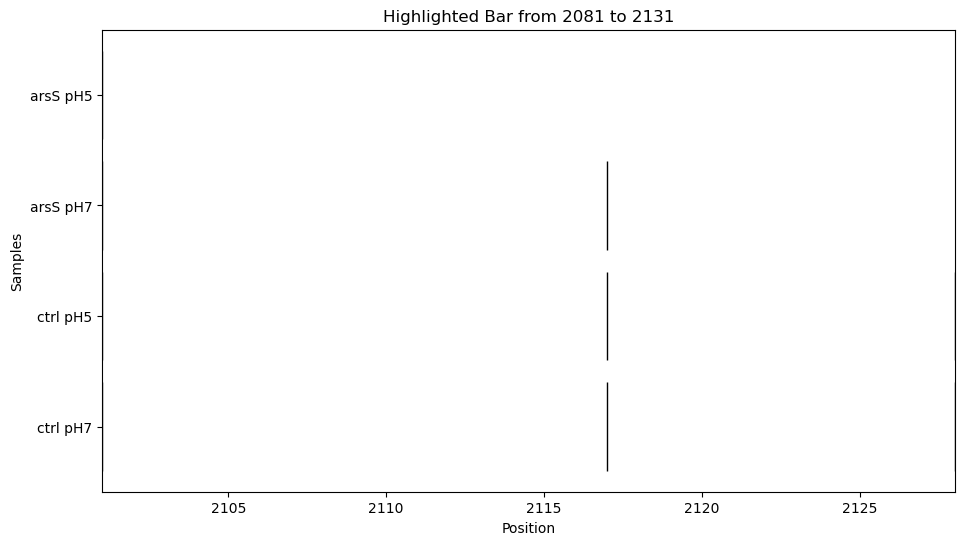

In [22]:
start_position = 2081
end_position = 2131

plot_bar_with_highlight(merge, start_position, end_position)

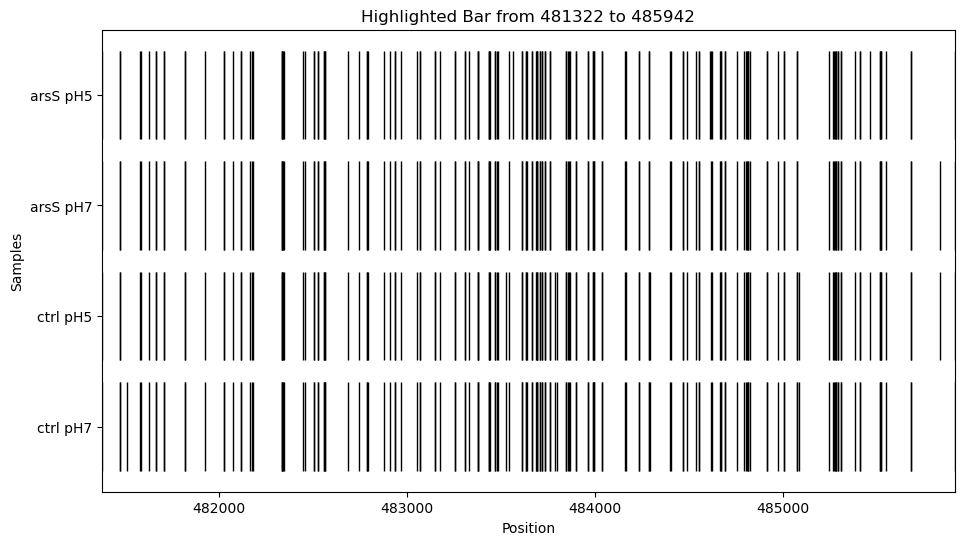

In [11]:
start_position = 481322
end_position = 485942

plot_bar_with_highlight(merge, start_position, end_position)

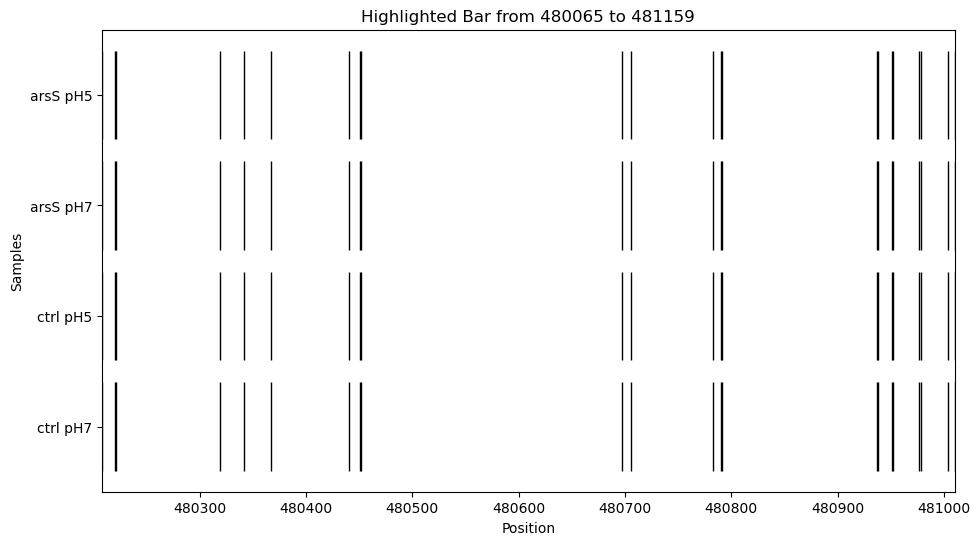

In [21]:
start_position = 480065
end_position = 481159

plot_bar_with_highlight(merge, start_position, end_position)

In [23]:
merge[(merge['start'] >= 2081) & (merge['end'] <= 2131)]

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
74,74,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,621,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,556,GAGG,587.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
75,75,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,137,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,559,NaN,85.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
76,76,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2128,2128,135,+,.,...,TGAGTTGCAAGCGCGCATTCAAACGCTCTGTAAGCCATGAA,527,HHTCAVNNNNNNTGY,85.0,HHTCAVNNNNNNTGY,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
59754,59754,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,521,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,440,GAGG,492.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
59755,59755,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,160,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,446,NaN,122.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
59756,59756,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2128,2128,115,+,.,...,TGAGTTGCAAGCGCGCATTCAAACGCTCTGTAAGCCATGAA,423,HTCAVNNNNNNTGY,75.0,HTCAVNNNNNNTGY,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
119420,119420,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,540,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,526,GAGG,508.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
119421,119421,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2117,2117,113,+,.,...,TAAGAGGTTGTTGAGTTGCAAGCGCGCATTCAAACGCTCTG,531,NaN,71.0,NaN,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE
178332,178332,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2101,2101,503,+,.,...,GAATGAAATCATAGCTTAAGAGGTTGTTGAGTTGCAAGCGC,483,GAGG,484.0,GAGG,Promoter and Coding Region,HP0003,HP0004,CENTRAL INTERMEDIARY METABOLISM,CELL ENVELOPE


In [8]:
hypomethylated_genes = [
    "HP0023", "HP0030", "HP0041", "HP0046", "HP0057", "HP0076", "HP0091", "HP0101", "HP0128", 
    "HP0135", "HP0161", "HP0165", "HP0225", "HP0253", "HP0256", "HP0274", "HP0291", "HP0315", 
    "HP0350", "HP0443", "HP0446", "HP0450", "HP0455", "HP0456", "HP0457", "HP0458", "HP0459", 
    "HP0461", "HP0481", "HP0493", "HP0495", "HP0503", "HP0521", "HP0533", "HP0536", "HP0560", 
    "HP0594", "HP0612", "HP0613", "HP0636", "HP0676", "HP0684", "HP0689", "HP0698", "HP0706", 
    "HP0713", "HP0755", "HP0767", "HP0796", "HP0800", "HP0802", "HP0849", "HP0857", "HP0873", 
    "HP0892", "HP0893", "HP0934", "HP0938", "HP0968", "HP0987", "HP0990", "HP0991", "HP0995", 
    "HP1000", "HP1003", "HP1009", "HP1015", "HP1033", "HP1054", "HP1086", "HP1093", "HP1094", 
    "HP1115", "HP1130", "HP1176", "HP1192", "HP1194", "HP1209", "HP1225", "HP1317", "HP1323", 
    "HP1351", "HP1405", "HP1408", "HP1412", "HP1419", "HP1423", "HP1444", "HP1474", "HP1485", 
    "HP1488", "HP1495", "HP1515", "HP1536"
]

In [9]:
filtered_df = merge[merge['gene_ID'].isin(hypomethylated_genes)]


In [11]:
filtered_df['gene_type'].value_counts()

gene_type
HYPOTHETICAL PROTEIEN                                         1419
CELL ENVELOPE                                                  320
REPLICATION                                                    303
CELLULAR PROCESSES                                             269
BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS     110
TRANSPORT AND BINDING PROTEINS                                  89
TRANSLATION                                                     84
OTHER CATEGORIES                                                77
ENERGY METABOLISM                                               64
PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES               40
Name: count, dtype: int64

In [14]:
filtered_df = annot[annot['HP_number'].isin(hypomethylated_genes)]


In [20]:
filtered_df[50:]

,HP_number,start,end,Putative_Id,Orf_Size,strand
801,HP0802,856624,857199,GTP cyclohydrolase II (ribA) {Haemophilus infl...,575,-
848,HP0849,900838,901125,hypothetical protein,287,-
856,HP0857,910341,910916,phosphoheptose isomerase (gmhA) {Escherichia c...,575,-
872,HP0873,924254,924466,hypothetical protein,212,-
891,HP0892,945694,945963,conserved hypothetical protein {Escherichia coli},269,-
892,HP0893,945980,946264,hypothetical protein,284,-
933,HP0934,994778,995530,conserved hypothetical protein {Escherichia coli},752,+
937,HP0938,999200,999544,hypothetical protein,344,-
967,HP0968,1027024,1027086,hypothetical protein,62,-
986,HP0987,1050812,1051042,hypothetical protein,230,+


In [24]:
hyper = ['HP0056', 'HP0103', 'HP0318', 'HP0319', 'HP0352', 'HP0351', 'HP0554', 'HP0590',
 'HP0777', 'HP0839', 'HP0843', 'HP0914', 'HP0985', 'HP1137', 'HP1410', 'HP1427',
 'HP1461', 'HP1460', 'HPnc8170', 'HPnc8160']

In [25]:
filtered_df = annot[annot['HP_number'].isin(hyper)]
filtered_df

,HP_number,start,end,Putative_Id,Orf_Size,strand
55,HP0056,57744,61298,delta-1-pyrroline-5-carboxylate dehydrogenase ...,3554,-
102,HP0103,109028,110722,methyl-accepting chemotaxis protein (tlpB) {Ba...,1694,-
317,HP0318,334391,335143,conserved hypothetical protein {Haemophilus in...,752,-
318,HP0319,335207,336829,arginyl-tRNA synthetase (argS) {Corynebacteriu...,1622,-
350,HP0351,359038,360738,flagellar basal-body M-ring protein (fliF) {Sa...,1700,+
351,HP0352,360759,361787,flagellar motor switch protein (fliG) {Borreli...,1028,+
553,HP0554,588768,589730,hypothetical protein,962,+
589,HP0590,621689,622507,"ferredoxin oxidoreductase, beta subunit {Metha...",818,+
776,HP0777,830285,831004,uridine 5'-monophosphate (UMP) kinase (pyrH) {...,719,-
838,HP0839,889715,891475,outer membrane protein P1 (ompP1) {Haemophilus...,1760,+


In [26]:
ctrl_diff = ['HP0010', 'HP0033', 'HP0065', 'HP0066', 'HP0186', 'HP0205', 'HP0220', 'HP0364', 'HP0402',
 'HP0407', 'HP0512', 'HP0544', 'HP0600', 'HP0610', 'HP0839', 'HP0922', 'HP0951', 'HP0970',
 'HP1083', 'HP1188', 'HP1213', 'HP1241', 'HP1361', 'HP1400']

In [32]:
ars_diff = ['HP0026', 'HP0247', 'HP0312', 'HP0965', 'HP1210', 'HP1247', 'HP1471', 'HP1550']

In [33]:
filtered_df = annot[annot['HP_number'].isin(ars_diff)]
filtered_df

,HP_number,start,end,Putative_Id,Orf_Size,strand
25,HP0026,26081,27358,citrate synthase (gltA) {Rickettsia prowazekii},1277,-
246,HP0247,255585,257060,"ATP-dependent RNA helicase, DEAD-box family (d...",1475,+
311,HP0312,327976,328938,conserved hypothetical ATP-binding protein {Es...,962,+
964,HP0965,1023253,1024581,hypothetical protein,1328,-
1209,HP1210,1286972,1287484,serine acetyltransferase (cysE) {Helicobacter ...,512,-
1246,HP1247,1321752,1322771,hypothetical protein,1019,-
1470,HP1471,1543446,1544636,type IIS restriction enzyme R protein (BCGIB) ...,1190,-
1549,HP1550,1629258,1630766,protein-export membrane protein (secD) {Escher...,1508,-
